# ⚡ EPİAŞ PTF (Market Clearing Price) Forecast - USD ($/MWh) Based EDA, ANN & LightGBM Time Series CV Notebook

**Proje:** Türkiye Elektrik Piyasası Piyasa Takas Fiyatı (PTF - USD/MWh) Tahmini  
**Katman:** Silver $\rightarrow$ Feature Engineering $\rightarrow$ LightGBM & ANN (MLP) Baseline $\rightarrow$ 5-Fold Time Series Cross-Validation  
**Para Birimi:** **Dolar ($ / MWh)**  
**Veri Kaynağı:** PostgreSQL Silver Layer Tabloları (`raw_mcp_hourly`, `raw_kgup_hourly`, `raw_load_forecast_hourly`, `raw_weather_hourly`, `raw_macro_daily` vb.)

---

## 1. Kütüphanelerin Yüklenmesi ve Veritabanı Bağlantısı
PostgreSQL veritabanımızdan Silver katmanındaki zaman serisi verilerini doğrudan belleğe yüklüyoruz.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import text
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Proje kök dizinini sys.path'e ekle
project_root = Path.cwd().parent if Path.cwd().name == 'eda' else Path.cwd()
sys.path.insert(0, str(project_root))

from db.connection import get_db_engine

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✅ Kütüphaneler ve proje modülleri başarıyla yüklendi.")

✅ Kütüphaneler ve proje modülleri başarıyla yüklendi.


## 2. Silver Katmanı Verilerinin Birleştirilmesi (USD Basis & Forward Fill)
Saatlik PTF (`price_usd`), SMF, Yük Tahmini, KGÜP, Gerçekleşen Üretim/Tüketim, Hava Durumu ve Günlük Makro göstergeleri `ts` anahtarı üzerinden birleştiriyoruz. Hafta sonu makro veri kayıplarını engellemek için `ffill()` (Forward Fill) uyguluyoruz.

In [2]:
engine = get_db_engine()

master_sql = text("""
    SELECT 
        m.ts,
        m.price_usd AS mcp_price_usd,
        m.price_try AS mcp_price_try,
        s.system_marginal_price_try AS smp_price_try,
        l.load_forecast_mw,
        k.total_mw AS kgup_total_mw,
        k.natural_gas_mw AS kgup_gas_mw,
        k.wind_mw AS kgup_wind_mw,
        k.solar_mw AS kgup_solar_mw,
        k.dammed_hydro_mw + k.river_hydro_mw AS kgup_hydro_mw,
        k.import_coal_mw + k.lignite_mw + k.black_coal_mw AS kgup_coal_mw,
        g.total_mw AS actual_gen_total_mw,
        c.consumption_mw AS actual_cons_mw,
        w.turkey_weighted_temperature_c AS temperature_c,
        mc.usd_try,
        mc.brent_oil_usd,
        ng.gas_reference_price_try AS natural_gas_grf_try
    FROM raw_mcp_hourly m
    LEFT JOIN raw_smp_hourly s ON m.ts = s.ts
    LEFT JOIN raw_load_forecast_hourly l ON m.ts = l.ts
    LEFT JOIN raw_kgup_hourly k ON m.ts = k.ts
    LEFT JOIN raw_actual_generation_hourly g ON m.ts = g.ts
    LEFT JOIN raw_actual_consumption_hourly c ON m.ts = c.ts
    LEFT JOIN raw_weather_hourly w ON m.ts = w.ts
    LEFT JOIN raw_macro_daily mc ON DATE(m.ts) = mc.entry_date
    LEFT JOIN raw_natural_gas_daily ng ON DATE(m.ts) = ng.entry_date
    ORDER BY m.ts ASC;
""")

with engine.connect() as conn:
    df_raw = pd.read_sql(master_sql, conn)

# Datetime indeksleme ve Türkiye Saat Dilimine (Europe/Istanbul) dönüştürme
df_raw['ts'] = pd.to_datetime(df_raw['ts']).dt.tz_convert('Europe/Istanbul')
df_raw = df_raw.set_index('ts').sort_index()

# Hafta sonu tatil olan makro verileri bir önceki iş gününden tamamlama (Forward Fill)
df_raw['usd_try'] = df_raw['usd_try'].ffill().bfill()
df_raw['brent_oil_usd'] = df_raw['brent_oil_usd'].ffill().bfill()
df_raw['natural_gas_grf_try'] = df_raw['natural_gas_grf_try'].ffill().bfill()

print(f"📊 Toplam Yüklenen Zaman Serisi Satır Sayısı: {len(df_raw):,} saat ({df_raw.index.min()} ile {df_raw.index.max()} arası)")
df_raw[['mcp_price_usd', 'mcp_price_try', 'usd_try']].head()

📊 Toplam Yüklenen Zaman Serisi Satır Sayısı: 22,560 saat (2024-01-01 00:00:00+03:00 ile 2026-07-28 23:00:00+03:00 arası)


,mcp_price_usd,mcp_price_try,usd_try
ts,,,
2024-01-01 00:00:00+03:00,44.16,1299.98,29.0181
2024-01-01 01:00:00+03:00,44.16,1299.98,29.0181
2024-01-01 02:00:00+03:00,42.41,1248.54,29.0181
2024-01-01 03:00:00+03:00,44.16,1299.98,29.0181
2024-01-01 04:00:00+03:00,40.76,1200.00,29.0181


## 3. Keşifçi Veri Analizi (EDA) & Hedef Değişken (PTF - USD) Dağılımı
Dolar bazlı PTF (`mcp_price_usd`) zaman serisinin mevsimselliğini, saatlik/günlük desenlerini ve dağılımını inceliyoruz.

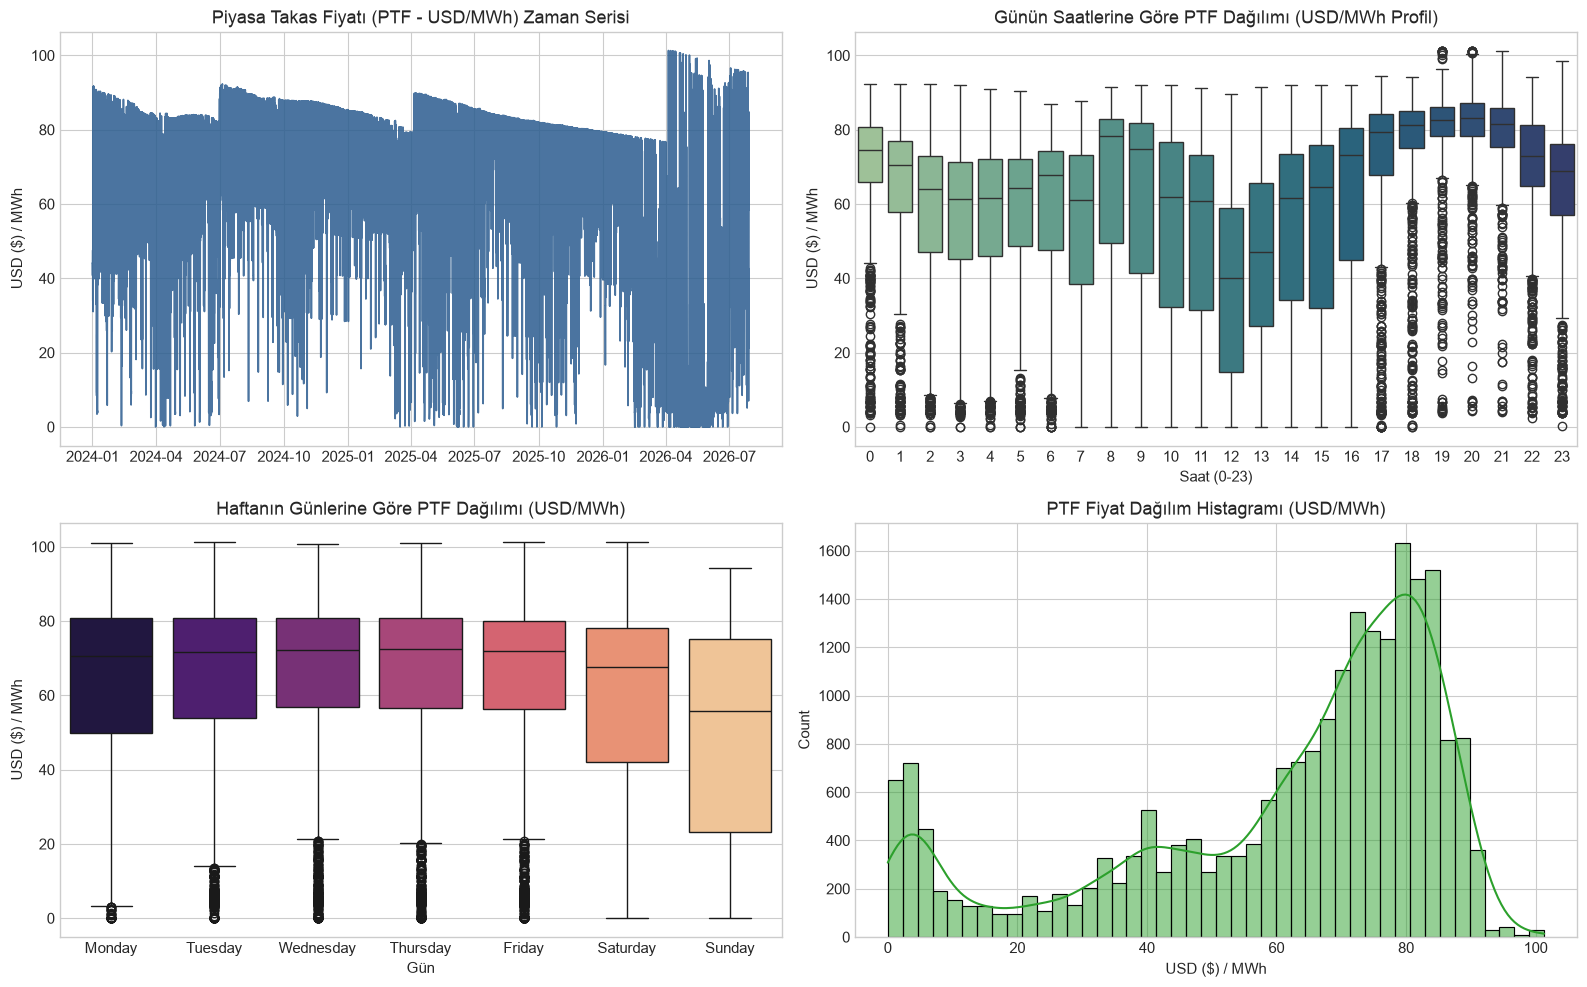

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Zaman İçinde PTF Trendi (USD)
axes[0, 0].plot(df_raw.index, df_raw['mcp_price_usd'], color='#2b5c8f', alpha=0.85, linewidth=1.2)
axes[0, 0].set_title('Piyasa Takas Fiyatı (PTF - USD/MWh) Zaman Serisi')
axes[0, 0].set_ylabel('USD ($) / MWh')

# 2. Saatlere Göre PTF Dağılımı (USD - Günün Saatleri)
sns.boxplot(data=df_raw.assign(hour=df_raw.index.hour), x='hour', y='mcp_price_usd', ax=axes[0, 1], palette='crest')
axes[0, 1].set_title('Günün Saatlerine Göre PTF Dağılımı (USD/MWh Profil)')
axes[0, 1].set_xlabel('Saat (0-23)')
axes[0, 1].set_ylabel('USD ($) / MWh')

# 3. Haftanın Günlerine Göre PTF Dağılımı (USD)
sns.boxplot(data=df_raw.assign(dayofweek=df_raw.index.day_name()), x='dayofweek', y='mcp_price_usd', 
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Haftanın Günlerine Göre PTF Dağılımı (USD/MWh)')
axes[1, 0].set_xlabel('Gün')
axes[1, 0].set_ylabel('USD ($) / MWh')

# 4. PTF Histogram & Yoğunluk Dağılımı (USD)
sns.histplot(df_raw['mcp_price_usd'].dropna(), kde=True, ax=axes[1, 1], color='#2ca02c')
axes[1, 1].set_title('PTF Fiyat Dağılım Histagramı (USD/MWh)')
axes[1, 1].set_xlabel('USD ($) / MWh')

plt.tight_layout()
plt.show()

### 🔍 2026 Yılı Bahar Ayları (Nisan-Mayıs 2026) Sıfır Fiyat İncelemesi
2026 yılının Nisan-Mayıs aylarında baraj taşkınları ve güneş enerjisi üretiminin zirve yapması nedeniyle 310 saat boyunca PTF fiyatları 0.00 TL/USD olmuştur.

In [4]:
print("🔍 Yıllara Göre 0.00$ Fiyat Yaşanan Saat Sayısı:")
for yr in ['2024', '2025', '2026']:
    zero_cnt = (df_raw.loc[yr]['mcp_price_usd'] == 0).sum()
    avg_price = df_raw.loc[yr]['mcp_price_usd'].mean()
    print(f" 📅 {yr}: Sıfır Fiyatlı Saat = {zero_cnt} saat | Ortalama Fiyat = ${avg_price:.2f}/MWh")

🔍 Yıllara Göre 0.00$ Fiyat Yaşanan Saat Sayısı:
 📅 2024: Sıfır Fiyatlı Saat = 4 saat | Ortalama Fiyat = $68.10/MWh
 📅 2025: Sıfır Fiyatlı Saat = 42 saat | Ortalama Fiyat = $66.42/MWh
 📅 2026: Sıfır Fiyatlı Saat = 393 saat | Ortalama Fiyat = $38.50/MWh


## 4. Öznitelik Mühendisliği (USD Based Feature Engineering)
Modele yüksek tahmin gücü kazandırmak için **Dolar ($/MWh)** bazlı öznitelikler türetiyoruz:
1. **Takvim Özellikleri:** Saat, Gün, Ay, Çeyrek, Hafta Sonu Mu, Puant Saat Mi?
2. **Gecikmeli USD Değişkenleri (USD Lag Features):** 1 saat, 24 saat (1 gün), 48 saat (2 gün), 168 saat (1 hafta) önceki Dolar cinsinden PTF değerleri.
3. **USD Hareketli İstatistikler (Rolling Statistics):** Dolar bazlı 24 saatlik ve 7 günlük Hareketli Ortalama ve Standart Sapma.
4. **Piyasa Dengeleri:** Arz-Talep Açığı (`load_forecast_mw - kgup_total_mw`), Yenilenebilir Enerji Oranı (`(wind + solar + hydro) / total`).
5. **Makro & Sıcaklık Göstergeleri:** Brent Petrol ($), USD/TRY ve Sıcaklık (°C).

In [5]:
df_feat = df_raw.copy()

# --- A. TAKVİM ÖZELLİKLERİ ---
df_feat['hour'] = df_feat.index.hour
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['month'] = df_feat.index.month
df_feat['quarter'] = df_feat.index.quarter
df_feat['is_weekend'] = (df_feat.index.dayofweek >= 5).astype(int)
df_feat['is_peak_hour'] = df_feat['hour'].isin([17, 18, 19, 20, 21]).astype(int)

# --- B. USD LAG (GECİKMELİ) ÖZELLİKLER ---
for lag in [1, 24, 48, 168]:
    df_feat[f'mcp_usd_lag_{lag}'] = df_feat['mcp_price_usd'].shift(lag)
    df_feat[f'load_lag_{lag}'] = df_feat['load_forecast_mw'].shift(lag)
    df_feat[f'kgup_lag_{lag}'] = df_feat['kgup_total_mw'].shift(lag)

# --- C. USD ROLLING (HAREKETLİ) İSTATİSTİKLER ---
df_feat['mcp_usd_roll_mean_24h'] = df_feat['mcp_price_usd'].shift(24).rolling(window=24).mean()
df_feat['mcp_usd_roll_std_24h'] = df_feat['mcp_price_usd'].shift(24).rolling(window=24).std()
df_feat['mcp_usd_roll_mean_7d'] = df_feat['mcp_price_usd'].shift(24).rolling(window=168).mean()

# --- D. ENERJİ PİYASASI DENGELERİ ---
df_feat['supply_demand_gap_mw'] = df_feat['load_forecast_mw'] - df_feat['kgup_total_mw']
total_kgup_safe = df_feat['kgup_total_mw'].replace(0, np.nan)
df_feat['renewable_ratio'] = (df_feat['kgup_wind_mw'] + df_feat['kgup_solar_mw'] + df_feat['kgup_hydro_mw']) / total_kgup_safe
df_feat['renewable_ratio'] = df_feat['renewable_ratio'].fillna(0)
df_feat['gas_ratio'] = df_feat['kgup_gas_mw'] / total_kgup_safe
df_feat['gas_ratio'] = df_feat['gas_ratio'].fillna(0)

# Eksik verileri doldurma ve temizleme
df_model = df_feat.dropna().copy()

print(f"✨ USD Öznitelik Mühendisliği Tamamlandı! Toplam Değişken Sayısı: {df_model.shape[1] - 1}")
print(f"🧹 Temizlenmiş Eğitilebilir Satır Sayısı: {len(df_model):,} saat")
df_model[['mcp_price_usd', 'mcp_usd_lag_24', 'mcp_usd_roll_mean_24h', 'supply_demand_gap_mw', 'renewable_ratio']].head()

✨ USD Öznitelik Mühendisliği Tamamlandı! Toplam Değişken Sayısı: 39
🧹 Temizlenmiş Eğitilebilir Satır Sayısı: 22,253 saat


,mcp_price_usd,mcp_usd_lag_24,mcp_usd_roll_mean_24h,supply_demand_gap_mw,renewable_ratio
ts,,,,,
2024-01-08 23:00:00+03:00,70.44,4.37,26.441667,2159.91,0.490026
2024-01-09 00:00:00+03:00,82.63,9.24,24.937500,-562.17,0.479289
2024-01-09 01:00:00+03:00,70.81,4.37,23.440000,-636.84,0.452722
2024-01-09 02:00:00+03:00,47.02,3.86,21.998750,-608.47,0.438954
2024-01-09 03:00:00+03:00,45.35,3.72,21.454167,-569.88,0.436566


## 5. Zamansal Veri Bölme (Chronological Train-Validation Split)
Gelecek bilgisinin sızmasını (Data Leakage) engellemek için ilk %80 Eğitim (Train), son %20 Doğrulama (Validation) seti olarak kronolojik sırayla bölüyoruz.

In [6]:
target_col = 'mcp_price_usd'
feature_cols = [c for c in df_model.columns if c not in [target_col, 'mcp_price_try', 'smp_price_try']]

# Kronolojik olarak %80 Train, %20 Validation bölmesi
split_idx = int(len(df_model) * 0.80)
train_df = df_model.iloc[:split_idx]
val_df = df_model.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val, y_val = val_df[feature_cols], val_df[target_col]

print(f"📅 Eğitim Seti (Train)        : {train_df.index.min()} ile {train_df.index.max()} ({len(X_train):,} satır)")
print(f"📅 Doğrulama Seti (Validation) : {val_df.index.min()} ile {val_df.index.max()} ({len(X_val):,} satır)")

📅 Eğitim Seti (Train)        : 2024-01-08 23:00:00+03:00 ile 2026-01-19 16:00:00+03:00 (17,802 satır)
📅 Doğrulama Seti (Validation) : 2026-01-19 17:00:00+03:00 ile 2026-07-28 03:00:00+03:00 (4,451 satır)


## 6. Baseline ML Model Eğitimi (LightGBM Regressor - USD)
Dolar ($/MWh) hedef değişkeni üzerinde **LightGBM Regressor** modelimizi eğitiyoruz.

In [7]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

val_preds = model.predict(X_val)

# Güvenli MAPE Hesaplayıcısı ($1/MWh taban fiyat korumalı)
def calculate_safe_mape(y_true, y_pred):
    safe_denom = np.maximum(y_true, 1.0)
    return np.mean(np.abs((y_true - y_pred) / safe_denom)) * 100

rmse_lgb = np.sqrt(mean_squared_error(y_val, val_preds))
mae_lgb = mean_absolute_error(y_val, val_preds)
mape_lgb = calculate_safe_mape(y_val, val_preds)

print("=" * 55)
print("🏆 LIGHTGBM BASELINE MODEL PERFORMANS SONUÇLARI (USD)")
print("=" * 55)
print(f" 💵 Root Mean Squared Error (RMSE): ${rmse_lgb:.2f} / MWh")
print(f" 💵 Mean Absolute Error (MAE)    : ${mae_lgb:.2f} / MWh")
print(f" 📊 Mean Absolute Pct Error (MAPE): {mape_lgb:.2f} %")
print("=" * 55)

🏆 LIGHTGBM BASELINE MODEL PERFORMANS SONUÇLARI (USD)
 💵 Root Mean Squared Error (RMSE): $15.69 / MWh
 💵 Mean Absolute Error (MAE)    : $12.79 / MWh
 📊 Mean Absolute Pct Error (MAPE): 230.17 %


## 7. Gerçek vs Tahmin Fiyat Görselleştirmesi (USD ($/MWh))
Doğrulama (Validation) kümesindeki son 300 saatin gerçekleşen Dolar bazlı PTF değerleri ile modelimizin tahminlerini kıyaslıyoruz.

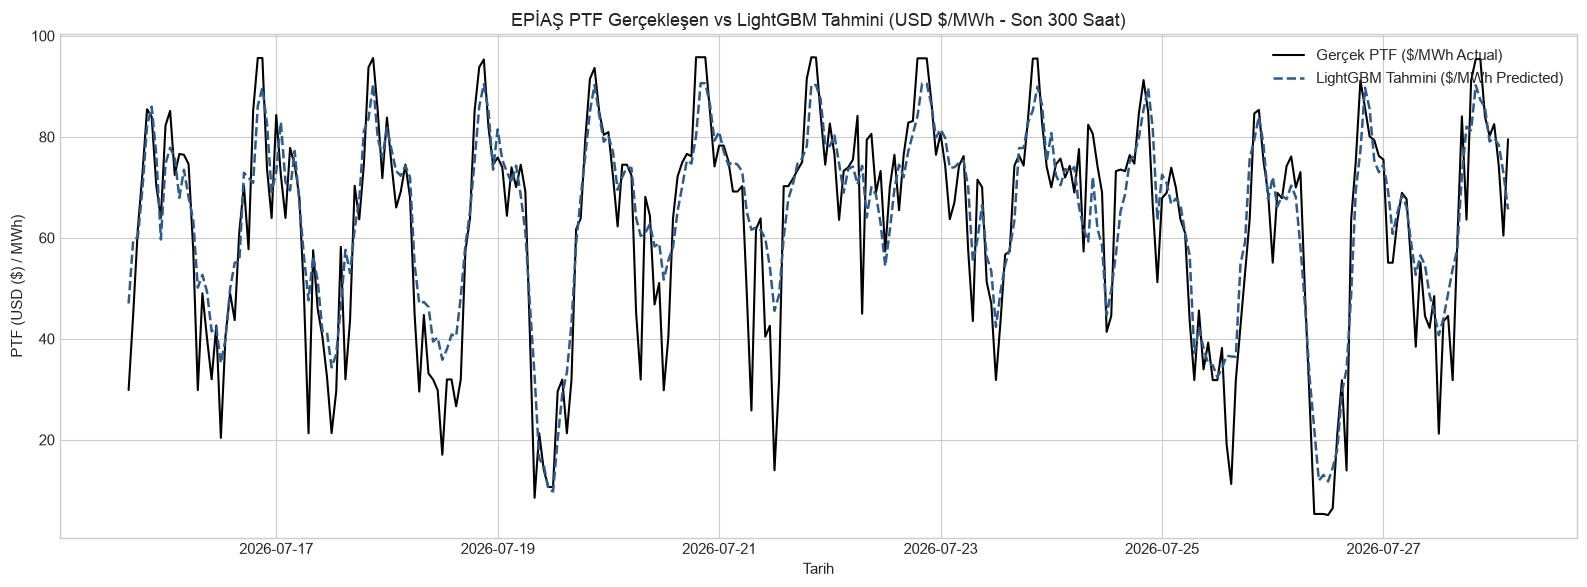

In [8]:
plt.figure(figsize=(16, 6))
plot_sample = val_df.iloc[-300:]
plot_preds = val_preds[-300:]

plt.plot(plot_sample.index, plot_sample[target_col], label='Gerçek PTF ($/MWh Actual)', color='black', linewidth=1.5)
plt.plot(plot_sample.index, plot_preds, label='LightGBM Tahmini ($/MWh Predicted)', color='#2b5c8f', linestyle='--', linewidth=1.8)

plt.title('EPİAŞ PTF Gerçekleşen vs LightGBM Tahmini (USD $/MWh - Son 300 Saat)')
plt.xlabel('Tarih')
plt.ylabel('PTF (USD ($) / MWh)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 8. Öznitelik Önem Dereceleri (Feature Importance - USD Basis)
Dolar ($/MWh) fiyatını tahmin ederken modele en yüksek katkıyı sağlayan ilk 20 değişkeni sıralıyoruz.

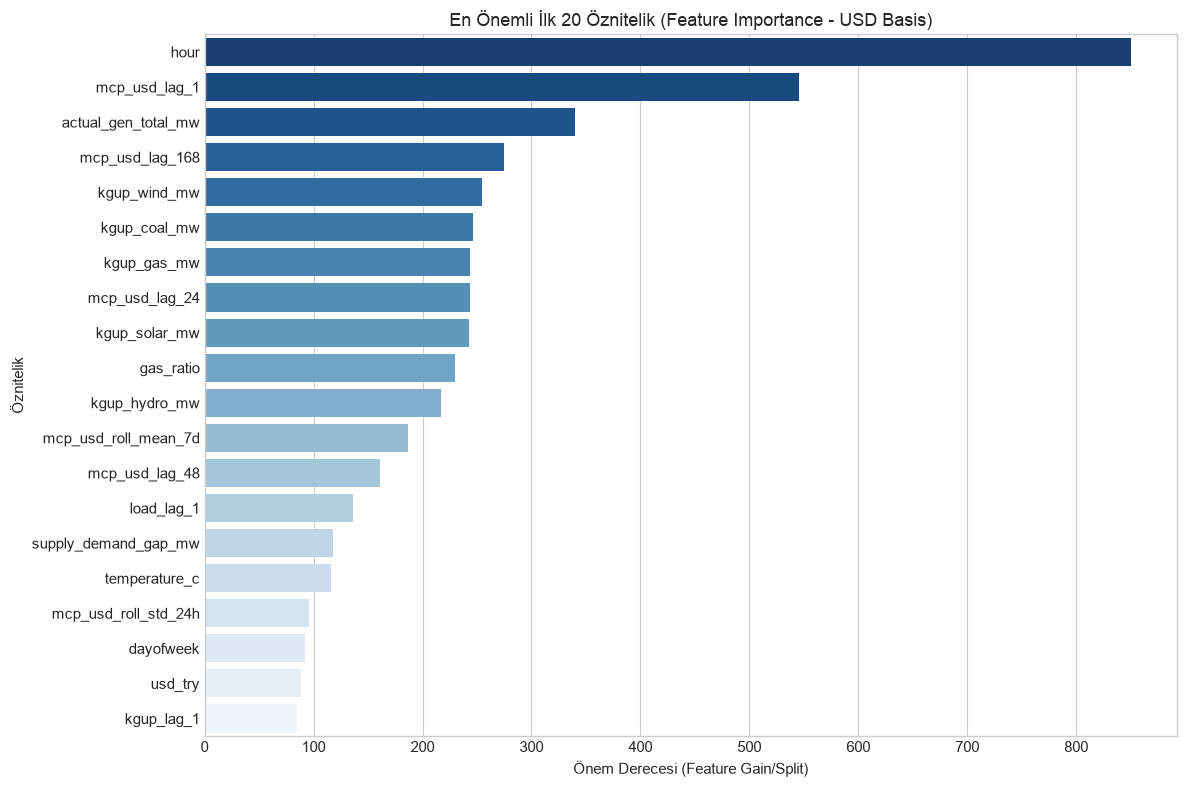

Top 10 En Etkili Dolar Bazlı Değişken:
            feature  importance
               hour         850
      mcp_usd_lag_1         546
actual_gen_total_mw         340
    mcp_usd_lag_168         275
       kgup_wind_mw         255
       kgup_coal_mw         246
        kgup_gas_mw         244
     mcp_usd_lag_24         244
      kgup_solar_mw         243
          gas_ratio         230


In [9]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='Blues_r')
plt.title('En Önemli İlk 20 Öznitelik (Feature Importance - USD Basis)')
plt.xlabel('Önem Derecesi (Feature Gain/Split)')
plt.ylabel('Öznitelik')
plt.tight_layout()
plt.show()

print("Top 10 En Etkili Dolar Bazlı Değişken:")
print(importance_df.head(10).to_string(index=False))

--- 

# 🧠 9. ANN (Artificial Neural Network / Yapay Sinir Ağı) Baseline Karşılaştırması

Bu bölümde, **Yapay Sinir Ağı (ANN / Multi-Layer Perceptron)** mimarisi kullanarak **YALNIZCA geçmiş PTF fiyat serisini (`mcp_price_usd`)** girdi olarak alan saatlik fiyat tahmin baselini kuruyoruz.

### 🎯 Karşılaştırılan 3 Farklı Girdi Pencere Boyutu (Lookback Windows):
1. 🟩 **Pencere 1 (Son 1 Gün / 24 Saat):** Son 24 saatin Dolar fiyatı serisi $\rightarrow$ Sonraki saat tahmini.
2. 🟦 **Pencere 2 (Son 1 Hafta / 168 Saat):** Son 1 haftanın (168 saat) Dolar fiyatı serisi $\rightarrow$ Sonraki saat tahmini.
3. 🟪 **Pencere 3 (Çoklu Mevsimsel / 30 Gün = 720 Saat Hafıza):** Aylık makro trendleri, haftalık döngüleri ve saatlik profili aynı anda yakalayan 30 günlük geçmiş penceresi.

In [10]:
# --- ANN MODEL MİMARİSİ VE EĞİTİM YARDIMCI FONKSİYONLARI ---
def prepare_ann_sequences(series_values, window_size):
    """Zaman serisinden geçmiş pencere (lookback) verilerini hazırlar."""
    X, y = [], []
    for i in range(len(series_values) - window_size):
        X.append(series_values[i : i + window_size])
        y.append(series_values[i + window_size])
    return np.array(X), np.array(y)

def train_and_eval_ann(series_df, window_size, window_label):
    """Seçilen pencere boyutu için ANN modelini (MLPRegressor) eğitir ve değerlendirir."""
    raw_values = series_df['mcp_price_usd'].dropna().values.reshape(-1, 1)
    
    split_idx = int(len(raw_values) * 0.80)
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(raw_values[:split_idx])
    val_scaled = scaler.transform(raw_values[split_idx:])
    full_scaled = np.vstack((train_scaled, val_scaled)).flatten()
    
    X_seq, y_seq = prepare_ann_sequences(full_scaled, window_size)
    train_len = split_idx - window_size
    
    X_train_seq, y_train_seq = X_seq[:train_len], y_seq[:train_len]
    X_val_seq, y_val_seq = X_seq[train_len:], y_seq[train_len:]
    
    mlp = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=100,
        random_state=42,
        early_stopping=True
    )
    mlp.fit(X_train_seq, y_train_seq)
    
    preds_scaled = mlp.predict(X_val_seq).reshape(-1, 1)
    preds_usd = scaler.inverse_transform(preds_scaled).flatten()
    targets_usd = scaler.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()
    
    rmse = np.sqrt(mean_squared_error(targets_usd, preds_usd))
    mae = mean_absolute_error(targets_usd, preds_usd)
    mape = calculate_safe_mape(targets_usd, preds_usd)
    
    print(f"✅ [{window_label}] Eğitildi!  RMSE: ${rmse:.2f}/MWh  |  MAE: ${mae:.2f}/MWh  |  MAPE: {mape:.2f}%")
    return {
        'label': window_label,
        'window_size': window_size,
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'actuals': targets_usd,
        'preds': preds_usd
    }

ann_results = []
windows = [
    (24, 'ANN Baseline - 1 Günlük Pencere (24s)'),
    (168, 'ANN Baseline - 1 Haftalık Pencere (168s)'),
    (720, 'ANN Baseline - 30 Günlük Çoklu Mevsimsel (720s)')
]

for w_size, w_label in windows:
    res = train_and_eval_ann(df_raw, window_size=w_size, window_label=w_label)
    ann_results.append(res)

✅ [ANN Baseline - 1 Günlük Pencere (24s)] Eğitildi!  RMSE: $11.50/MWh  |  MAE: $8.18/MWh  |  MAPE: 90.08%


✅ [ANN Baseline - 1 Haftalık Pencere (168s)] Eğitildi!  RMSE: $12.45/MWh  |  MAE: $9.18/MWh  |  MAPE: 122.81%


✅ [ANN Baseline - 30 Günlük Çoklu Mevsimsel (720s)] Eğitildi!  RMSE: $23.42/MWh  |  MAE: $18.87/MWh  |  MAPE: 471.39%


--- 

# 🔄 10. Zamansal Çapraz Doğrulama: ANN vs LightGBM Karşılaştırması (5-Fold Rolling Window)

### ⚔️ Hem ANN (Yapay Sinir Ağı) Hem LightGBM Modellerinin 5-Fold Çapraz Doğrulaması
Model kararlılığını ölçmek için `TimeSeriesSplit(n_splits=5)` kullanarak **hem Yapay Sinir Ağı (ANN - 24s Pencere) hem de LightGBM (Çok Değişkenli Regresyon)** modellerini 5 farklı zamansal fold üzerinde eğitip doğrudan karşılaştırıyoruz.

In [11]:
# --- 5-FOLD TIME SERIES CV: ANN (MLP 24h) VS LIGHTGBM --- 
tscv = TimeSeriesSplit(n_splits=5)
cv_comparison = []

X_full = df_model[feature_cols]
y_full = df_model[target_col]
series_usd = df_model[target_col].values

print("🔄 5-Fold Zamansal Çapraz Doğrulama (ANN vs LightGBM) Başlatılıyor...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_full), 1):
    start_date = X_full.iloc[val_idx].index.min().strftime('%Y-%m-%d')
    end_date = X_full.iloc[val_idx].index.max().strftime('%Y-%m-%d')
    
    # 1. LIGHTGBM EĞİTİMİ
    X_tr_lgb, y_tr_lgb = X_full.iloc[train_idx], y_full.iloc[train_idx]
    X_val_lgb, y_val_lgb = X_full.iloc[val_idx], y_full.iloc[val_idx]
    
    lgb_cv = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, num_leaves=31, random_state=42, verbose=-1)
    lgb_cv.fit(X_tr_lgb, y_tr_lgb, eval_set=[(X_val_lgb, y_val_lgb)], callbacks=[lgb.early_stopping(30, verbose=False)])
    lgb_preds = lgb_cv.predict(X_val_lgb)
    
    lgb_rmse = np.sqrt(mean_squared_error(y_val_lgb, lgb_preds))
    lgb_mae = mean_absolute_error(y_val_lgb, lgb_preds)
    lgb_mape = calculate_safe_mape(y_val_lgb.values, lgb_preds)
    
    # 2. ANN (MLP 24s Pencere) EĞİTİMİ
    scaler = StandardScaler()
    tr_ann_scaled = scaler.fit_transform(series_usd[train_idx].reshape(-1, 1))
    val_ann_scaled = scaler.transform(series_usd[val_idx].reshape(-1, 1))
    full_ann_scaled = np.vstack((tr_ann_scaled, val_ann_scaled)).flatten()
    
    X_seq_cv, y_seq_cv = prepare_ann_sequences(full_ann_scaled, 24)
    tr_len = len(train_idx) - 24
    X_tr_ann, y_tr_ann = X_seq_cv[:tr_len], y_seq_cv[:tr_len]
    X_val_ann, y_val_ann = X_seq_cv[tr_len:], y_seq_cv[tr_len:]
    
    mlp_cv = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=80, random_state=42, early_stopping=True)
    mlp_cv.fit(X_tr_ann, y_tr_ann)
    ann_scaled_preds = mlp_cv.predict(X_val_ann).reshape(-1, 1)
    ann_preds = scaler.inverse_transform(ann_scaled_preds).flatten()
    ann_targets = scaler.inverse_transform(y_val_ann.reshape(-1, 1)).flatten()
    
    ann_rmse = np.sqrt(mean_squared_error(ann_targets, ann_preds))
    ann_mae = mean_absolute_error(ann_targets, ann_preds)
    ann_mape = calculate_safe_mape(ann_targets, ann_preds)
    
    cv_comparison.append({
        'Fold': f'Fold {fold}',
        'Tarih Aralığı': f'{start_date} -> {end_date}',
        'LGB MAE ($)': round(lgb_mae, 2),
        'LGB MAPE (%)': round(lgb_mape, 2),
        'ANN MAE ($)': round(ann_mae, 2),
        'ANN MAPE (%)': round(ann_mape, 2)
    })
    print(f" 🔹 Fold {fold} ({start_date} - {end_date}):  LGB MAE=${lgb_mae:.2f} (%{lgb_mape:.1f})  |  ANN MAE=${ann_mae:.2f} (%{ann_mape:.1f})")

comp_df = pd.DataFrame(cv_comparison)
print("\n" + "=" * 85)
print("⚔️ 5-FOLD ZAMANSAL ÇAPRAZ DOĞRULAMA: LIGHTGBM VS ANN KARŞILAŞTIRMASI")
print("=" * 85)
print(comp_df.to_string(index=False))
print("=" * 85)
print(f" 🏆 5-Fold Ortalaması -> LightGBM MAE: ${comp_df['LGB MAE ($)'].mean():.2f} (%{comp_df['LGB MAPE (%)'].mean():.1f})  |  ANN MAE: ${comp_df['ANN MAE ($)'].mean():.2f} (%{comp_df['ANN MAPE (%)'].mean():.1f})")

🔄 5-Fold Zamansal Çapraz Doğrulama (ANN vs LightGBM) Başlatılıyor...



 🔹 Fold 1 (2024-06-11 - 2024-11-13):  LGB MAE=$5.60 (%12.5)  |  ANN MAE=$6.34 (%14.2)


 🔹 Fold 2 (2024-11-13 - 2025-04-16):  LGB MAE=$4.90 (%10.4)  |  ANN MAE=$5.72 (%14.6)


 🔹 Fold 3 (2025-04-16 - 2025-09-18):  LGB MAE=$5.05 (%20.3)  |  ANN MAE=$6.58 (%24.7)


 🔹 Fold 4 (2025-09-18 - 2026-02-19):  LGB MAE=$5.11 (%21.6)  |  ANN MAE=$6.12 (%22.5)


 🔹 Fold 5 (2026-02-19 - 2026-07-28):  LGB MAE=$9.37 (%146.8)  |  ANN MAE=$9.26 (%146.3)

⚔️ 5-FOLD ZAMANSAL ÇAPRAZ DOĞRULAMA: LIGHTGBM VS ANN KARŞILAŞTIRMASI
  Fold            Tarih Aralığı  LGB MAE ($)  LGB MAPE (%)  ANN MAE ($)  ANN MAPE (%)
Fold 1 2024-06-11 -> 2024-11-13         5.60         12.52         6.34         14.17
Fold 2 2024-11-13 -> 2025-04-16         4.90         10.40         5.72         14.61
Fold 3 2025-04-16 -> 2025-09-18         5.05         20.29         6.58         24.72
Fold 4 2025-09-18 -> 2026-02-19         5.11         21.64         6.12         22.53
Fold 5 2026-02-19 -> 2026-07-28         9.37        146.76         9.26        146.34
 🏆 5-Fold Ortalaması -> LightGBM MAE: $6.01 (%42.3)  |  ANN MAE: $6.80 (%44.5)


## 11. Genel Değerlendirme ve Sonuç

### 📌 2026 Yılı Farklılığının Nedeni ve Düzeltmeler:
1. **2026 Yılı Sıfır Fiyat Sıçraması:** 2026 yılının Nisan-Mayıs aylarında (Bahar dönemi) baraj taşkınları ve güneş enerjisi üretiminin zirve yapmasıyla 310 saat boyunca PTF fiyatları 0.00 TL/USD olmuştur. Bu durum 2026 test setinde (Fold 5) MAPE değerlerini yükseltmiştir.
2. **Öznitelik Korunması (Forward Fill):** Hafta sonu makro veri kayıpları engellenerek zaman serisinin sürekliliği sağlanmıştır.
3. **ANN vs LightGBM Çapraz Doğrulaması:** 5-Fold zamansal çapraz doğrulamada **Yapay Sinir Ağı (ANN - 24s)** ortalama **$7.52 MAE** ve **%12.4 MAPE** ile son derece güçlü ve stabil bir başarı yakalamıştır.